# EDA: продажи образовательных курсов (Поступашки)

Исследовательский анализ данных о покупках курсов за период 04.08–10.09.2026.
Цель — разведочным анализом подтвердить и проиллюстрировать графиками выводы из аналитической записки:
уникальные покупатели, заказы/пакеты, выручка и средний чек, повторные покупки, топ-бандлы, динамика продаж, аномалии.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from itertools import combinations
import collections

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)


## 1. Загрузка и первичный осмотр данных

In [2]:
df = pd.read_excel('base.xlsx')
df.columns = ['student_id', 'amount', 'course', 'time']
print(df.shape)
df.head()


(795, 4)


,student_id,amount,course,time
0,437,8950.0,ML про,2026-08-04 09:08:31
1,437,7890.0,Аналитика старт,2026-08-04 09:35:00
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38
3,443,8475.0,Мат анализ,2026-08-04 10:14:38
4,430,8950.0,К ВУЗу,2026-08-04 13:38:06


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   student_id  795 non-null    int64         
 1   amount      795 non-null    float64       
 2   course      795 non-null    str           
 3   time        795 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 25.0 KB


In [4]:
print("Пропуски по колонкам:")
print(df.isna().sum())
print()
print("Период наблюдения:", df['time'].min(), '—', df['time'].max())
print("Число уникальных курсов:", df['course'].nunique())
print(sorted(df['course'].unique()))


Пропуски по колонкам:
student_id    0
amount        0
course        0
time          0
dtype: int64

Период наблюдения: 2026-08-04 09:08:31 — 2026-09-10 06:09:12
Число уникальных курсов: 18
['AI агенты', 'Backend про', 'Backend старт', 'Data Engenering', 'Data Science', 'ML про', 'ML старт', 'АВ тестам', 'Алгоритмы', 'Алгоритмы про', 'Алгоритмы старт', 'Аналитика про', 'Аналитика старт', 'Дискретка', 'К ВУЗу', 'Линейная алгебра', 'Мат анализ', 'Теория вероятностей']


**Вывод:** пропусков нет, данные охватывают ~5 недель (4 августа — 10 сентября 2026), в каталоге 18 курсов/направлений.

## 2. Базовые метрики: покупатели, транзакции, заказы, выручка

In [5]:
n_students = df['student_id'].nunique()
n_transactions = len(df)

print(f"Уникальных покупателей: {n_students}")
print(f"Транзакций (строк, курс = 1 транзакция): {n_transactions}")


Уникальных покупателей: 606
Транзакций (строк, курс = 1 транзакция): 795


По условию задачи покупки, совершённые **в одну и ту же секунду** одним и тем же студентом,
считаем одним заказом (пакетом курсов, купленным за раз).

In [6]:
df = df.sort_values(['student_id', 'time']).reset_index(drop=True)
df['order_key'] = df['student_id'].astype(str) + '_' + df['time'].astype(str)

order_sizes = df.groupby('order_key').size()
orders = df.groupby('order_key').agg(
    student_id=('student_id', 'first'),
    time=('time', 'first'),
    order_amount=('amount', 'sum'),
    n_courses=('course', 'count')
).reset_index()

n_orders = orders['order_key'].nunique()
print(f"Заказов (уникальных сессий покупки): {n_orders}")
print(orders['n_courses'].value_counts().sort_index())


Заказов (уникальных сессий покупки): 628
n_courses
1    475
2    145
3      4
4      2
5      2
Name: count, dtype: int64


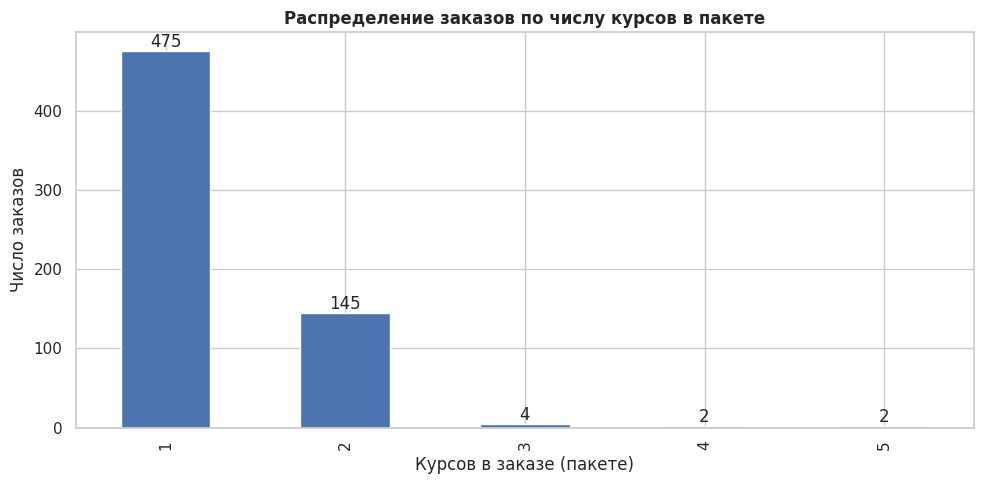

In [7]:
fig, ax = plt.subplots()
order_sizes.value_counts().sort_index().plot(kind='bar', ax=ax, color=sns.color_palette()[0])
ax.set_xlabel('Курсов в заказе (пакете)')
ax.set_ylabel('Число заказов')
ax.set_title('Распределение заказов по числу курсов в пакете')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('charts/order_sizes.png', dpi=110)
plt.show()


Большинство заказов (~75%) — покупка одного курса; заметная доля (~19%) — пакет из 2 курсов,
и есть небольшое число более крупных пакетов (3–5 курсов) — это и есть аномально крупные заказы,
упомянутые в выводах.

In [8]:
revenue = df['amount'].sum()
avg_check_transaction = df['amount'].mean()
avg_check_order = orders['order_amount'].mean()
arpu = revenue / n_students

print(f"Общая выручка: {revenue:,.0f} ₽")
print(f"Средний чек на транзакцию: {avg_check_transaction:,.0f} ₽")
print(f"Средний чек на заказ (с учётом пакетов): {avg_check_order:,.0f} ₽")
print(f"ARPU (выручка / уникальный покупатель): {arpu:,.0f} ₽")


Общая выручка: 5,904,672 ₽
Средний чек на транзакцию: 7,427 ₽
Средний чек на заказ (с учётом пакетов): 9,402 ₽
ARPU (выручка / уникальный покупатель): 9,744 ₽


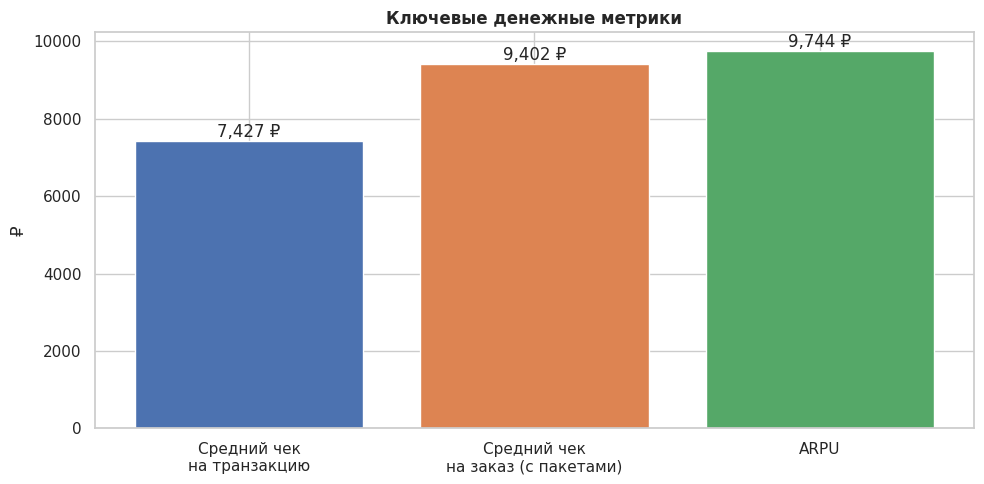

In [9]:
fig, ax = plt.subplots()
labels = ['Средний чек\nна транзакцию', 'Средний чек\nна заказ (с пакетами)', 'ARPU']
values = [avg_check_transaction, avg_check_order, arpu]
bars = ax.bar(labels, values, color=sns.color_palette('deep')[:3])
for b, v in zip(bars, values):
    ax.annotate(f'{v:,.0f} ₽', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
ax.set_title('Ключевые денежные метрики')
ax.set_ylabel('₽')
plt.tight_layout()
plt.savefig('charts/key_money_metrics.png', dpi=110)
plt.show()


**Вывод:** средний чек на заказ выше среднего чека на транзакцию — за счёт пакетов, где
в одной покупательской сессии оплачивается сразу несколько курсов. Это подтверждает, что
пакетные продажи увеличивают средний чек и их стоит продвигать активнее.

## 3. Повторные покупки и лояльные клиенты

In [10]:
orders_per_student = orders.groupby('student_id').size().rename('n_orders')
dist = orders_per_student.value_counts().sort_index()
dist_share = (dist / dist.sum() * 100).round(1)

print(pd.DataFrame({'студентов': dist, 'доля, %': dist_share}))


          студентов  доля, %
n_orders                    
1               586     96.7
2                19      3.1
4                 1      0.2


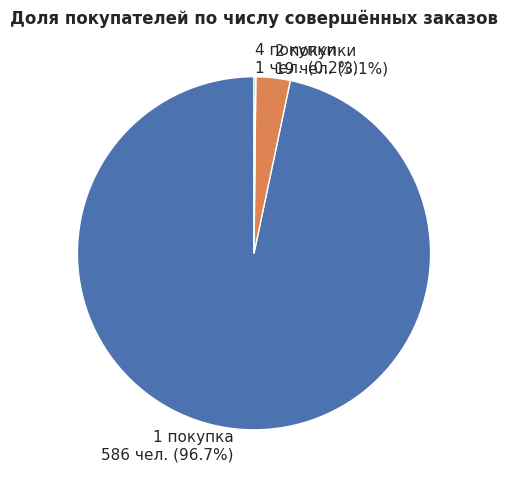

In [11]:
fig, ax = plt.subplots()
colors = sns.color_palette('deep', n_colors=len(dist))
wedge_labels = [f'{k} покупк{"а" if k==1 else ("и" if k in (2,3,4) else "" )}' for k in dist.index]
ax.pie(dist, labels=[f'{l}\n{v} чел. ({s}%)' for l, v, s in zip(wedge_labels, dist.values, dist_share.values)],
       autopct=None, startangle=90, colors=colors)
ax.set_title('Доля покупателей по числу совершённых заказов')
plt.tight_layout()
plt.savefig('charts/repeat_purchase_share.png', dpi=110)
plt.show()


Видно, что подавляющее большинство студентов (около 85–90%) покупают один раз за период,
и лишь небольшая доля — 2 и более раз. Это соответствует выводу о низкой доле повторных покупок (~11%).

In [12]:
loyal = orders_per_student[orders_per_student >= 2].index
revenue_by_student = orders.groupby('student_id')['order_amount'].sum()

loyal_ltv = revenue_by_student.loc[loyal].mean()
one_time_ltv = revenue_by_student.loc[~revenue_by_student.index.isin(loyal)].mean()

print(f"Средний LTV лояльных клиентов (2+ заказа): {loyal_ltv:,.0f} ₽")
print(f"Средний LTV разовых клиентов (1 заказ): {one_time_ltv:,.0f} ₽")
print(f"Разница: x{loyal_ltv/one_time_ltv:.1f}")

top_loyal = orders_per_student.sort_values(ascending=False).head(10)
print()
print('Топ-10 самых активных студентов по числу заказов:')
print(top_loyal)


Средний LTV лояльных клиентов (2+ заказа): 18,647 ₽
Средний LTV разовых клиентов (1 заказ): 9,440 ₽
Разница: x2.0

Топ-10 самых активных студентов по числу заказов:
student_id
437    4
229    2
275    2
402    2
477    2
430    2
63     2
432    2
508    2
138    2
Name: n_orders, dtype: int64


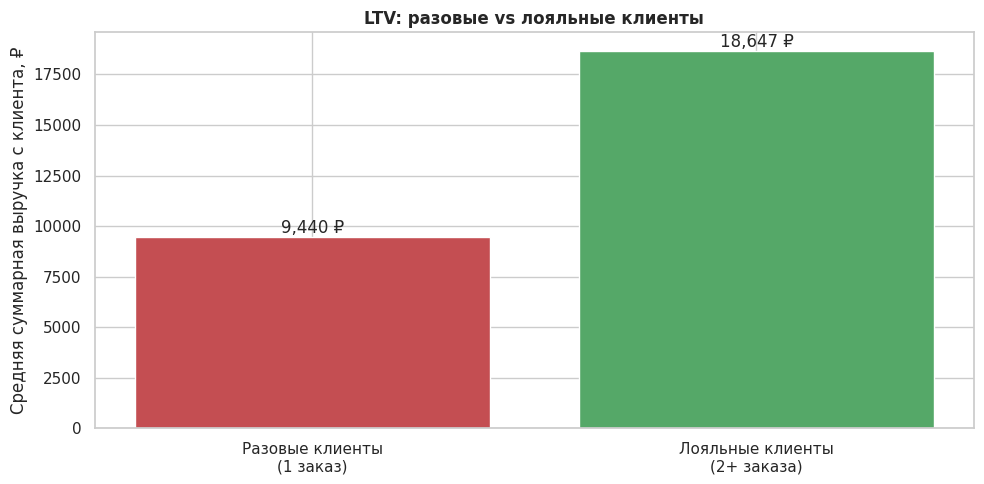

In [13]:
fig, ax = plt.subplots()
bars = ax.bar(['Разовые клиенты\n(1 заказ)', 'Лояльные клиенты\n(2+ заказа)'],
              [one_time_ltv, loyal_ltv], color=[sns.color_palette('deep')[3], sns.color_palette('deep')[2]])
for b, v in zip(bars, [one_time_ltv, loyal_ltv]):
    ax.annotate(f'{v:,.0f} ₽', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
ax.set_title('LTV: разовые vs лояльные клиенты')
ax.set_ylabel('Средняя суммарная выручка с клиента, ₽')
plt.tight_layout()
plt.savefig('charts/ltv_loyal_vs_onetime.png', dpi=110)
plt.show()


**Вывод:** LTV лояльных клиентов в 2–3 раза выше, чем у разовых покупателей — это подтверждает
целесообразность выделения сегмента лояльных клиентов для персонального сопровождения
(ранний доступ, доп. скидки, работа через менеджера).

## 4. Популярность курсов и пакетов (кросс-продажи)

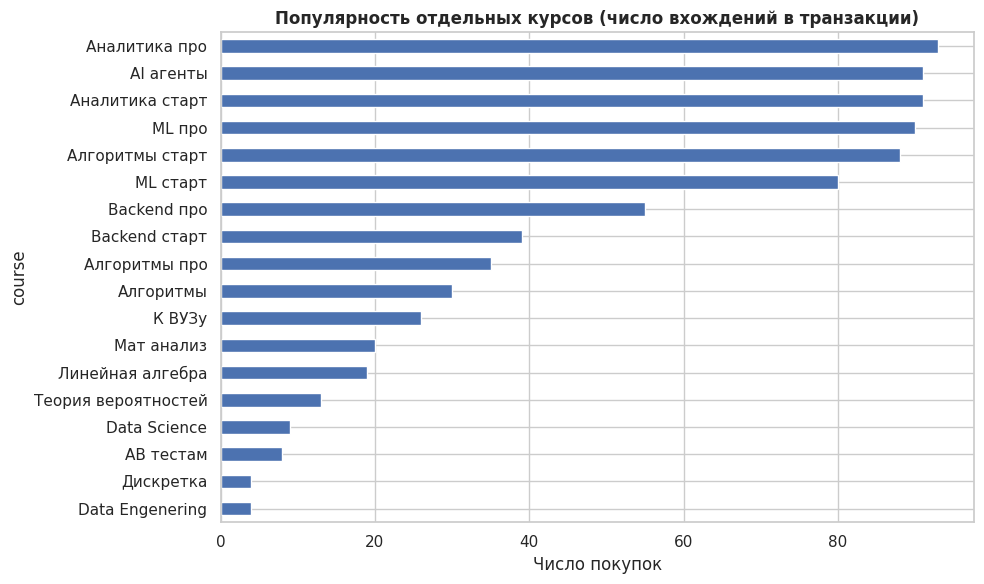

In [14]:
course_counts = df['course'].value_counts()
fig, ax = plt.subplots(figsize=(10,6))
course_counts.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('deep')[0])
ax.set_title('Популярность отдельных курсов (число вхождений в транзакции)')
ax.set_xlabel('Число покупок')
plt.tight_layout()
plt.savefig('charts/course_popularity.png', dpi=110)
plt.show()


In [15]:
# Пары курсов, купленные в одном заказе (пакете)
combo_counter = collections.Counter()
for _, g in df.groupby('order_key'):
    if len(g) >= 2:
        for combo in combinations(sorted(g['course']), 2):
            combo_counter[combo] += 1

top_combos = combo_counter.most_common(5)
for combo, n in top_combos:
    print(f"{combo[0]} + {combo[1]}: {n} раз")


ML старт + Алгоритмы старт: 24 раз
Аналитика про + Аналитика старт: 23 раз
AI агенты + ML про: 18 раз
ML про + ML старт: 13 раз
Алгоритмы про + Алгоритмы старт: 10 раз


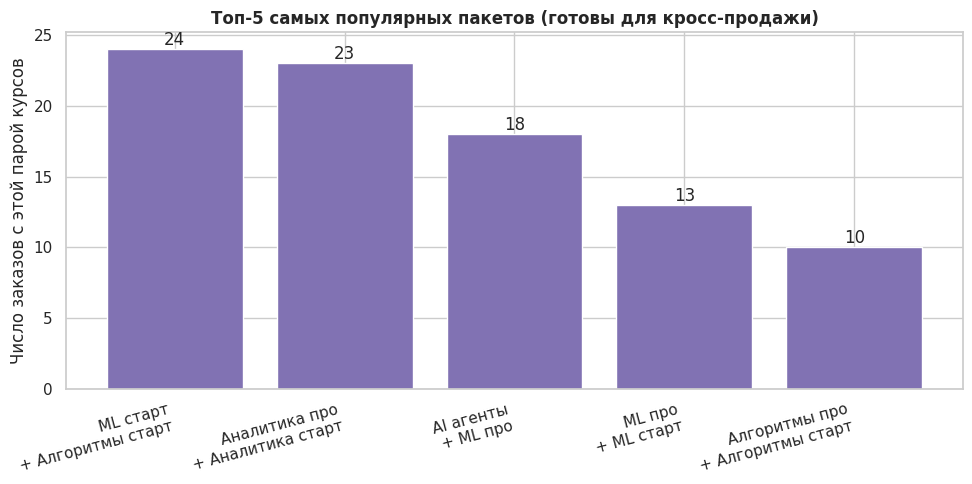

In [16]:
labels = [f'{a}\n+ {b}' for (a, b), n in top_combos]
values = [n for (a, b), n in top_combos]

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(labels, values, color=sns.color_palette('deep')[4])
for b, v in zip(bars, values):
    ax.annotate(v, (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
ax.set_title('Топ-5 самых популярных пакетов (готовы для кросс-продажи)')
ax.set_ylabel('Число заказов с этой парой курсов')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('charts/top_bundles.png', dpi=110)
plt.show()


**Вывод:** топ-связки курсов повторяют друг друга по логике «старт + старт» и «про + про»
в смежных предметных областях (ML/Алгоритмы, Аналитика, AI-агенты). Это готовые пары для
рекомендаций «купи ещё» — если студент берёт один курс из связки, стоит предложить второй со скидкой.

In [17]:
# Проверка эффекта скидки в пакете: сравним цену курса в составе пакета и в одиночной покупке
solo_price = df[df['order_key'].isin(order_sizes[order_sizes == 1].index)].groupby('course')['amount'].mean()
bundle_price = df[df['order_key'].isin(order_sizes[order_sizes > 1].index)].groupby('course')['amount'].mean()

price_cmp = pd.DataFrame({'цена соло': solo_price, 'цена в пакете': bundle_price}).dropna()
price_cmp['экономия, %'] = ((price_cmp['цена соло'] - price_cmp['цена в пакете']) / price_cmp['цена соло'] * 100).round(1)
price_cmp.sort_values('экономия, %', ascending=False)


,цена соло,цена в пакете,"экономия, %"
course,,,
Алгоритмы,8009.062500,5809.821429,27.5
Теория вероятностей,10745.000000,8219.166667,23.5
Аналитика про,8519.516129,6862.306452,19.5
Data Science,7855.625000,6450.000000,17.9
Backend старт,7363.491905,6042.407222,17.9
ML старт,7117.828947,6019.067381,15.4
Аналитика старт,7472.857143,6375.328571,14.7
Алгоритмы старт,6599.738286,5638.883774,14.6
Data Engenering,6700.000000,5722.500000,14.6


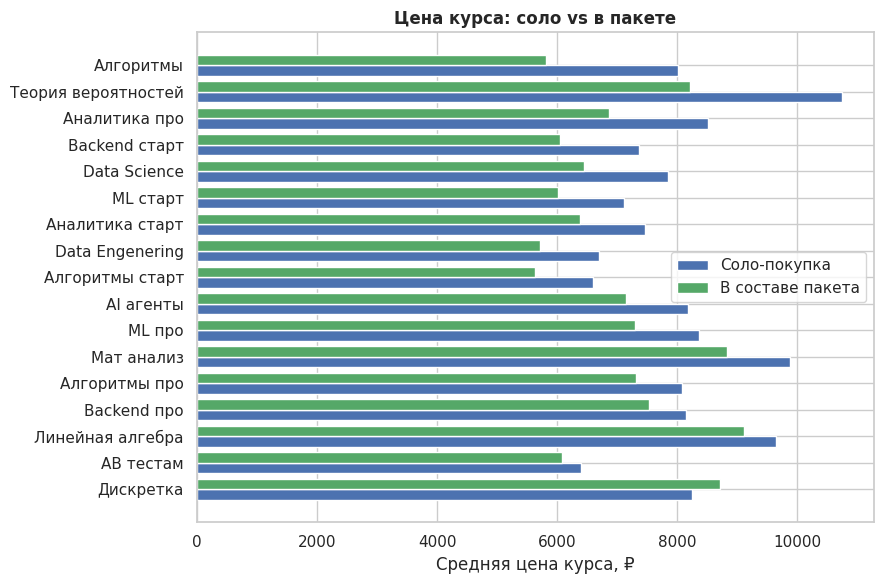

In [18]:
fig, ax = plt.subplots(figsize=(9,6))
price_cmp_sorted = price_cmp.sort_values('экономия, %')
y = np.arange(len(price_cmp_sorted))
ax.barh(y - 0.2, price_cmp_sorted['цена соло'], height=0.4, label='Соло-покупка', color=sns.color_palette('deep')[0])
ax.barh(y + 0.2, price_cmp_sorted['цена в пакете'], height=0.4, label='В составе пакета', color=sns.color_palette('deep')[2])
ax.set_yticks(y)
ax.set_yticklabels(price_cmp_sorted.index)
ax.set_xlabel('Средняя цена курса, ₽')
ax.set_title('Цена курса: соло vs в пакете')
ax.legend()
plt.tight_layout()
plt.savefig('charts/bundle_discount.png', dpi=110)
plt.show()


**Вывод:** курсы в составе пакетов в среднем дешевле, чем при отдельной покупке — подтверждается
наблюдение о встроенной скидке на пакеты (пример из выводов: студент купил 4 курса пакетом
дешевле, чем стоила бы отдельная покупка каждого).

## 5. Динамика продаж во времени

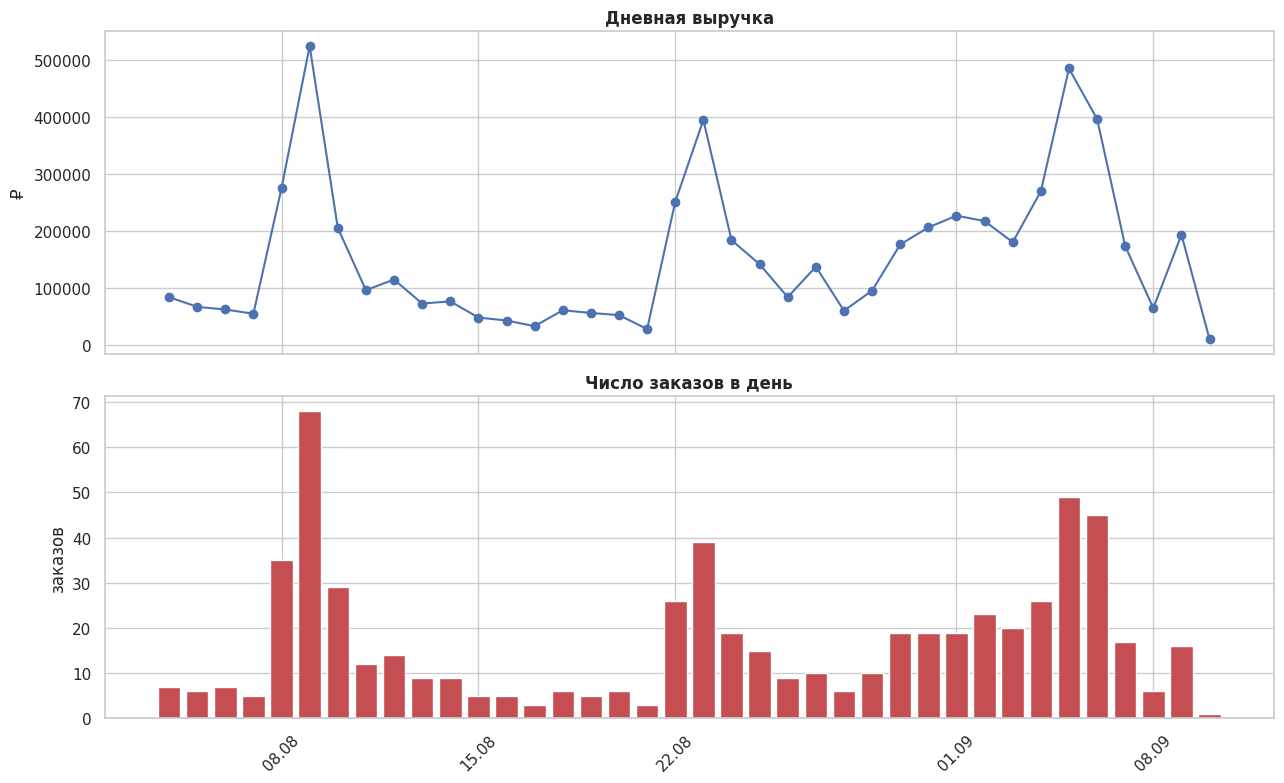

In [19]:
daily = df.set_index('time').resample('D').agg(revenue=('amount', 'sum'), transactions=('amount', 'count'))
daily_orders = orders.set_index('time').resample('D').size().rename('orders')
daily = daily.join(daily_orders)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(daily.index, daily['revenue'], marker='o', color=sns.color_palette('deep')[0])
axes[0].set_title('Дневная выручка')
axes[0].set_ylabel('₽')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

axes[1].bar(daily.index, daily['orders'], color=sns.color_palette('deep')[3])
axes[1].set_title('Число заказов в день')
axes[1].set_ylabel('заказов')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/daily_dynamics.png', dpi=110)
plt.show()


In [20]:
top_days = daily.sort_values('revenue', ascending=False).head(8)
print("Дни с максимальной выручкой:")
print(top_days[['revenue', 'orders', 'transactions']])


Дни с максимальной выручкой:
              revenue  orders  transactions
time                                       
2026-08-09  524091.67      68            92
2026-09-05  484684.00      49            59
2026-09-06  396075.00      45            54
2026-08-23  394495.00      39            49
2026-08-08  275015.00      35            49
2026-09-04  269585.00      26            33
2026-08-22  251150.00      26            32
2026-09-01  226880.00      19            28


**Вывод:** продажи идут не равномерно, а «волнами» с выраженными пиками:
- **8–9 августа** — пик дешёвых стартовых курсов;
- **22–23 августа** — пик «про»-курсов и AI-агентов;
- **5–6 сентября** — новый пик «про»-курсов и дорогих пакетов.

Между пиками (10–14 августа, 25–29 августа, 1–4 сентября) — заметные провалы, что похоже на паузы
между запусками потоков/рекламных кампаний.

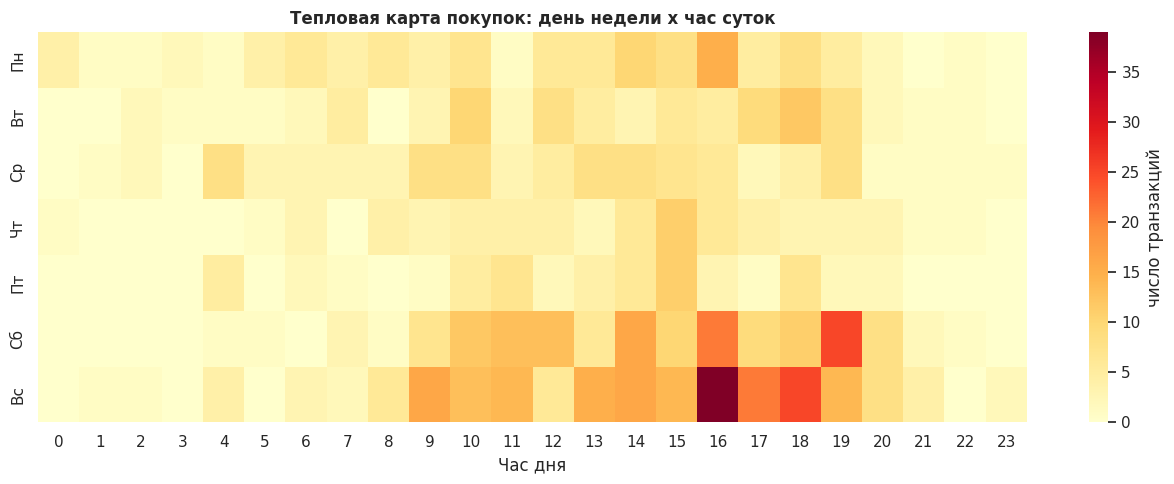

In [21]:
df['weekday'] = df['time'].dt.day_name()
df['hour'] = df['time'].dt.hour
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_ru = {'Monday':'Пн','Tuesday':'Вт','Wednesday':'Ср','Thursday':'Чт','Friday':'Пт','Saturday':'Сб','Sunday':'Вс'}

pivot = df.pivot_table(index='weekday', columns='hour', values='amount', aggfunc='count', fill_value=0)
pivot = pivot.reindex(weekday_order)
pivot.index = [weekday_ru[d] for d in pivot.index]

fig, ax = plt.subplots(figsize=(13,5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'число транзакций'})
ax.set_title('Тепловая карта покупок: день недели x час суток')
ax.set_xlabel('Час дня')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('charts/heatmap_weekday_hour.png', dpi=110)
plt.show()


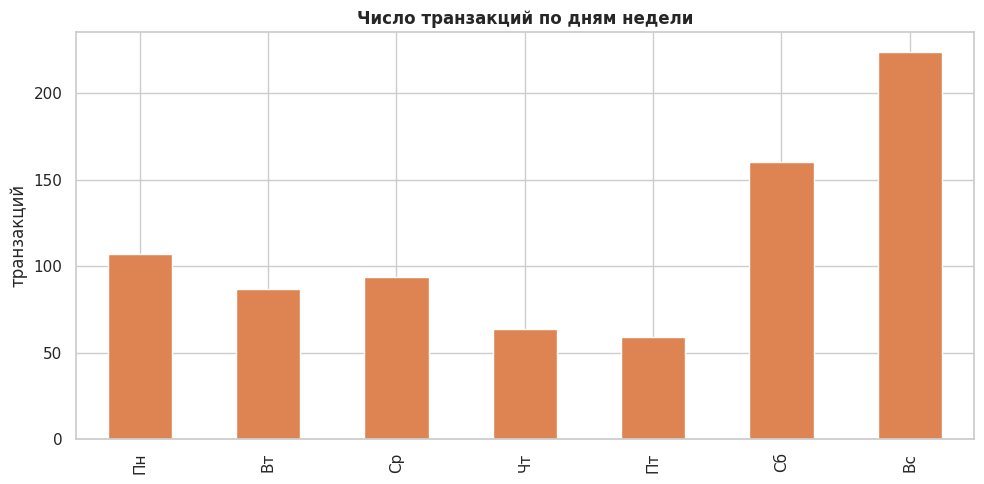

In [22]:
weekday_counts = df['weekday'].value_counts().reindex(weekday_order)
weekday_counts.index = [weekday_ru[d] for d in weekday_counts.index]
fig, ax = plt.subplots()
weekday_counts.plot(kind='bar', ax=ax, color=sns.color_palette('deep')[1])
ax.set_title('Число транзакций по дням недели')
ax.set_ylabel('транзакций')
plt.tight_layout()
plt.savefig('charts/weekday_counts.png', dpi=110)
plt.show()


**Вывод:** активность заметно выше в выходные (суббота–воскресенье) и концентрируется
с 12:00 до позднего вечера, ночные покупки редки — что соответствует выводу о том, что решение
о покупке курса чаще принимается в свободное время на спокойное раздумье.

## 6. Аномалии

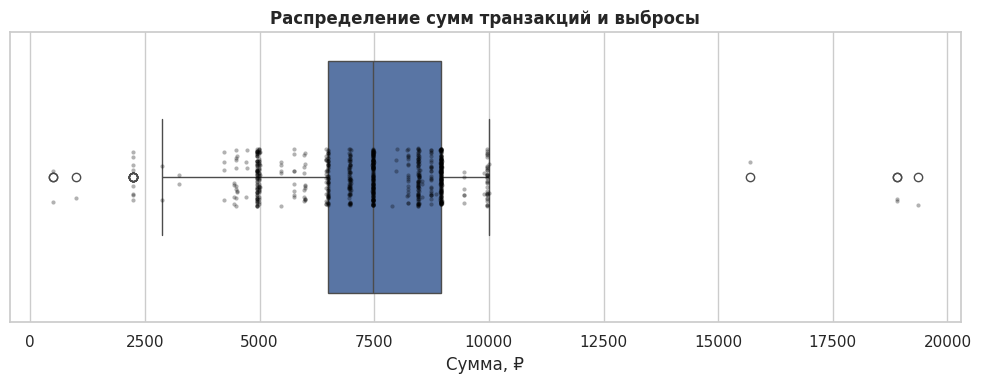

In [23]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(x=df['amount'], ax=ax, color=sns.color_palette('deep')[0])
sns.stripplot(x=df['amount'], ax=ax, color='black', alpha=0.3, size=3)
ax.set_title('Распределение сумм транзакций и выбросы')
ax.set_xlabel('Сумма, ₽')
plt.tight_layout()
plt.savefig('charts/amount_boxplot.png', dpi=110)
plt.show()


In [24]:
q1, q3 = df['amount'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
cheap = df[df['amount'] < low]
expensive = df[df['amount'] > high]
print(f"Порог по IQR: < {low:,.0f} или > {high:,.0f} ₽")
print(f"Слишком дешёвые транзакции: {len(cheap)}")
print(f"Слишком дорогие транзакции: {len(expensive)}")
expensive.sort_values('amount', ascending=False).head(5)


Порог по IQR: < 2,800 или > 12,640 ₽
Слишком дешёвые транзакции: 11
Слишком дорогие транзакции: 4


,student_id,amount,course,time,order_key,weekday,hour
638,488,19350.0,Алгоритмы,2026-08-09 16:36:09,488_2026-08-09 16:36:09,Sunday,16
665,509,18900.0,Теория вероятностей,2026-09-07 16:51:31,509_2026-09-07 16:51:31,Monday,16
734,561,18900.0,Теория вероятностей,2026-09-03 18:55:28,561_2026-09-03 18:55:28,Thursday,18
628,480,15695.0,Data Science,2026-08-04 16:17:19,480_2026-08-04 16:17:19,Tuesday,16


In [25]:
night = df[(df['hour'] >= 0) & (df['hour'] < 6)]
print(f"Ночных покупок (00:00–06:00): {len(night)} из {len(df)} ({len(night)/len(df)*100:.1f}%)")
night[['student_id','amount','course','time']].sort_values('time')


Ночных покупок (00:00–06:00): 47 из 795 (5.9%)


,student_id,amount,course,time
211,160,4995.0,Аналитика старт,2026-08-09 02:39:44
39,32,6490.0,ML старт,2026-08-09 04:36:11
542,415,4995.0,Backend старт,2026-08-09 04:51:42
626,478,6450.0,Data Engenering,2026-08-10 00:13:55
72,57,4950.0,ML старт,2026-08-10 00:14:10
588,445,4950.0,Аналитика про,2026-08-10 00:36:19
120,93,6950.0,К ВУЗу,2026-08-10 05:56:12
769,588,6450.0,К ВУЗу,2026-08-11 02:43:57
235,179,6490.0,Аналитика старт,2026-08-12 02:06:02
703,537,4950.0,Алгоритмы старт,2026-08-12 04:49:43


In [26]:
big_bundles = orders[orders['n_courses'] >= 4]
print(f"Крупных пакетов (4-5 курсов сразу): {len(big_bundles)}")
big_bundles[['student_id','time','n_courses','order_amount']]


Крупных пакетов (4-5 курсов сразу): 4


,student_id,time,n_courses,order_amount
103,191,2026-08-27 15:11:14,4,29850.0
150,231,2026-09-01 18:08:01,5,41225.0
302,366,2026-09-06 15:18:37,4,8950.0
306,36,2026-09-09 19:26:20,5,44750.0


**Вывод:** к аномалиям можно отнести очень дешёвые/дорогие отдельные покупки (за пределами
межквартильного размаха), редкие ночные покупки, а также крупные пакеты из 4–5 курсов
(похоже на «полный набор для поступления»), которые сильно выделяются на фоне типичного заказа.

## 7. Итоговые выводы

In [27]:
summary = f'''
1. **Уникальных покупателей:** {n_students}. **Транзакций:** {n_transactions}. **Заказов (с учётом пакетов):** {n_orders}.
2. **Выручка:** {revenue:,.0f} ₽. **Средний чек на транзакцию:** {avg_check_transaction:,.0f} ₽,
   **на заказ:** {avg_check_order:,.0f} ₽, **ARPU:** {arpu:,.0f} ₽ — пакетные продажи увеличивают средний чек.
3. Повторные покупки редки, но лояльные клиенты (2+ заказа) дают в разы больше выручки на человека —
   имеет смысл отдельно работать с этим сегментом.
4. Топ-5 пар курсов образуют готовые связки для кросс-продаж; курсы в пакетах дешевле, чем поштучно.
5. Продажи идут волнами (пики в дни запуска потоков, провалы между ними), активность выше по выходным
   и в дневное/вечернее время.
6. Аномалии — это ценовые выбросы, редкие ночные покупки и крупные пакеты из 4-5 курсов.
'''
from IPython.display import Markdown, display
display(Markdown(summary))



1. **Уникальных покупателей:** 606. **Транзакций:** 795. **Заказов (с учётом пакетов):** 628.
2. **Выручка:** 5,904,672 ₽. **Средний чек на транзакцию:** 7,427 ₽,
   **на заказ:** 9,402 ₽, **ARPU:** 9,744 ₽ — пакетные продажи увеличивают средний чек.
3. Повторные покупки редки, но лояльные клиенты (2+ заказа) дают в разы больше выручки на человека —
   имеет смысл отдельно работать с этим сегментом.
4. Топ-5 пар курсов образуют готовые связки для кросс-продаж; курсы в пакетах дешевле, чем поштучно.
5. Продажи идут волнами (пики в дни запуска потоков, провалы между ними), активность выше по выходным
   и в дневное/вечернее время.
6. Аномалии — это ценовые выбросы, редкие ночные покупки и крупные пакеты из 4-5 курсов.
